In [14]:
%reload_ext autoreload
%autoreload 2

In [15]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [16]:
from waymo_agent.notebook_imports import *

In [17]:
from functools import cache

In [18]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic

In [19]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *

In [20]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [21]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [22]:
from waymo_agent.models.evaluate import *

### Heuristic Agents

In [23]:
env_cfg = EnvConfig(
    max_episode_steps=60 * 1,
    vehicle_per_node=0.10,
    lambda_per_node=0.05,
    max_pending_requests=100,
    max_new_requests_per_step=20,
)
plt_cfg = PlotConfig()
env_heuristic = RideShareEnv(env_cfg, plot_config=plt_cfg)

Assigned lambda values to nodes. Total lambda: 39.1000 (target: 39.1000)


In [24]:
price_agent = PricingAgent(env_heuristic.config)
dispatch_agent = DispatchAgent(env_heuristic)
reposition_agent = RepositionAgent(env_heuristic)
agents = (price_agent, dispatch_agent, reposition_agent)

### Actor-Critic PPO Model

In [25]:
# env_cfg = EnvConfig(max_episode_steps=60 * 3)
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 39.1000 (target: 39.1000)


In [26]:
from waymo_agent.models.torch_np_utils import load_weights
from waymo_agent.models.train_utils import PPOTrainConfig


cfg_ppo = PPOTrainConfig()
model = RideShareActorCritic(env_model)
load_weights(model, MODEL_WEIGHT_DIR / "ppo_model_final.pt", DEVICE_TORCH_STR)

RideShareActorCritic(
  (encoder): SharedEncoder(
    (net): Sequential(
      (0): Linear(in_features=1908, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
  )
  (pricing): PricingHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (reposition): RepositionHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (dispatch): DispatchHead(
    (logits_layer): Linear(in_features=256, out_features=5100, bias=True)
  )
  (value): Linear(in_features=256, out_features=1, bias=True)
)

In [27]:
r, info = run_episode(
    env_model,
    policy_fn=ppo_policy_stochastic(model),
    seed=0,
    show_progress=True,
    desc="PPO rollout",
)
r

PPO rollout:   0%|          | 0/60 [00:00<?, ?step/s]

-700.0416216573678

In [28]:
r, info = run_episode(
    env_heuristic,
    policy_fn=heuristic_policy(agents),
    seed=0,
    show_progress=True,
    desc="Heuristic rollout",
)

Heuristic rollout:   0%|          | 0/60 [00:00<?, ?step/s]

In [29]:
seeds = list(range(5))
results = eval_paired_seeds(
    env_model,
    env_heuristic,
    ppo_policy_stochastic(model),  # policy fn
    heuristic_policy(agents),  # policy fn
    seeds=seeds,
)
results

Evaluating policies:   0%|          | 0/5 [00:00<?, ?episode/s]

{'seeds': array([0, 1, 2, 3, 4]),
 'ppo': array([-658.80335148, -753.47958962, -721.79154645, -758.32655332,
        -742.99824265]),
 'heur': array([731.99385299, 762.96284239, 764.66343627, 758.59630512,
        741.57721253]),
 'diff': array([-1390.79720447, -1516.44243201, -1486.45498272, -1516.92285844,
        -1484.57545517]),
 'ppo_mean': -727.0798567034165,
 'ppo_std': 40.67045718330065,
 'heur_mean': 751.9587298589572,
 'heur_std': 14.430260508882904,
 'diff_mean': -1479.0385865623737,
 'diff_std': 51.73602968475955,
 'win_rate': 0.0}

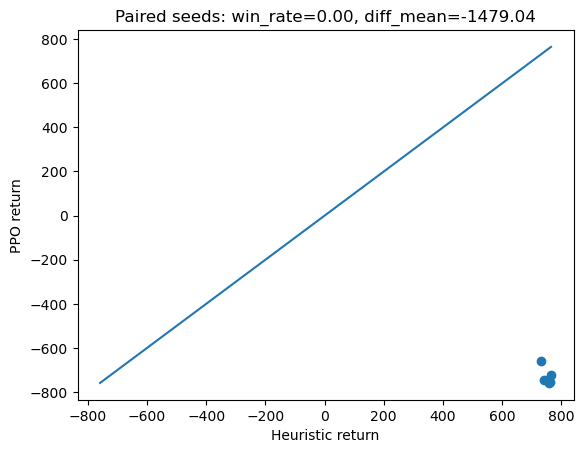

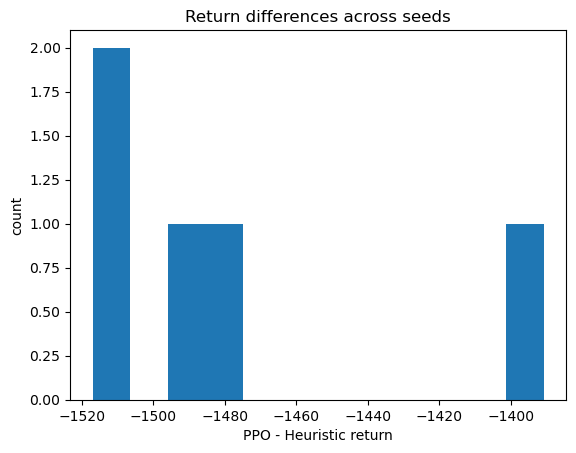

In [30]:
plot_min_eval(results)

In [31]:
results.keys()

dict_keys(['seeds', 'ppo', 'heur', 'diff', 'ppo_mean', 'ppo_std', 'heur_mean', 'heur_std', 'diff_mean', 'diff_std', 'win_rate'])

In [ ]:
import torch, math


def fmt_gb(x):
    return f"{x/1024**3:.2f} GB"


if torch.backends.mps.is_available():
    rec = torch.mps.recommended_max_memory()
    drv = torch.mps.driver_allocated_memory()
    cur = torch.mps.current_allocated_memory()
    print("MPS recommended max:", fmt_gb(rec))
    print("MPS driver allocated:", fmt_gb(drv), f"({drv/rec:.1%} of recommended)")
    print("MPS current allocated:", fmt_gb(cur), "(tensors only, excludes cache)")
else:
    print("MPS not available on this machine.")

MPS recommended max: 24.96 GB
MPS driver allocated: 0.06 GB (0.2% of recommended)
MPS current allocated: 0.02 GB (tensors only, excludes cache)
